In [8]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

np.random.seed(42)
random.seed(42)

# --- Configuration ---
NUM_CUSTOMERS = 1000
NUM_TRANSACTIONS = 15000
START_DATE = datetime(2025, 1, 1)
END_DATE = datetime(2025, 12, 31)

# --- 1. Generate Customers ---
def generate_customers():
    print("Generating Customers...")
    customer_ids = range(1, NUM_CUSTOMERS + 1)
    
    # Customer Demographics
    ages = np.random.normal(loc=35, scale=12, size=NUM_CUSTOMERS).astype(int)
    ages = np.clip(ages, 18, 80)
    
    genders = np.random.choice(['F', 'M', 'Other'], size=NUM_CUSTOMERS, p=[0.55, 0.42, 0.03])
    
    # Introduce missing values for a small percentage
    countries = np.random.choice(['USA', 'UK', 'Canada', 'Australia', 'Germany'], size=NUM_CUSTOMERS, p=[0.6, 0.15, 0.1, 0.08, 0.07])
    countries = [c if random.random() > 0.02 else None for c in countries]

    # Customer Segments (Hidden from the final dataset, but drives behavior)
    # High Value (15%), Regular (60%), Churned/Infrequent (25%)
    segments = np.random.choice(['High', 'Regular', 'Infrequent'], size=NUM_CUSTOMERS, p=[0.15, 0.60, 0.25])
    
    customers_df = pd.DataFrame({
        'customer_id': customer_ids,
        'age': ages,
        'gender': genders,
        'country': countries,
        '_segment': segments # Hidden column used for generation logic
    })
    return customers_df

# --- 2. Generate Transactions ---
def generate_transactions(customers_df):
    print("Generating Transactions...")
    
    products = {
        'Electronics': {'price_range': (100, 1500), 'prob': 0.3},
        'Clothing': {'price_range': (20, 150), 'prob': 0.4},
        'Home & Kitchen': {'price_range': (15, 300), 'prob': 0.2},
        'Books': {'price_range': (5, 40), 'prob': 0.1}
    }
    
    transaction_data = []
    
    for _ in range(NUM_TRANSACTIONS):
        # 1. Pick a customer based on segment weights
        # High value buy more often, infrequent buy rarely
        weights = customers_df['_segment'].map({'High': 5, 'Regular': 2, 'Infrequent': 0.5})
        customer = customers_df.sample(weights=weights).iloc[0]
        
        # 2. Generate Date (Add seasonal trend)
        # Higher probability of transactions in Nov/Dec (Holiday season)
        while True:
            days_between = (END_DATE - START_DATE).days
            random_days = random.randrange(days_between)
            txn_date = START_DATE + timedelta(days=random_days)
            
            # Seasonal weighting: Higher chance to accept dates in Q4
            if txn_date.month in [11, 12]:
                if random.random() < 0.8: break # 80% chance to keep a holiday date
            else:
                if random.random() < 0.3: break # 30% chance to keep non-holiday date

        # Add time
        txn_datetime = txn_date + timedelta(hours=random.randint(0, 23), minutes=random.randint(0, 59))

        # 3. Pick Product Category
        category = np.random.choice(list(products.keys()), p=[p['prob'] for p in products.values()])
        
        # 4. Generate Price (High value customers tend to buy more expensive items)
        min_price, max_price = products[category]['price_range']
        if customer['_segment'] == 'High':
            # Skew price higher
            price = np.random.triangular(min_price, max_price, max_price)
        else:
            price = np.random.uniform(min_price, max_price)
            
        price = round(price, 2)
        
        # 5. Quantity
        quantity = np.random.choice([1, 2, 3, 4, 5], p=[0.7, 0.15, 0.08, 0.05, 0.02])
        
        # 6. Returns (Status)
        # Electronic have higher return rate. 
        return_prob = 0.08 if category == 'Electronics' else 0.04
        status = 'Returned' if random.random() < return_prob else 'Completed'
        
        # Introduce some data quality issues (dirty data)
        # Occasional negative quantity or weird string in price
        if random.random() < 0.005: quantity = quantity * -1
        
        final_price = price
        if random.random() < 0.002: final_price = f"${price}" # Add $ sign to some
        
        
        transaction_data.append({
            'transaction_id': f"TXN_{random.randint(100000, 999999)}",
            'customer_id': customer['customer_id'],
            'transaction_date': txn_datetime,
            'product_category': category,
            'unit_price': final_price,
            'quantity': quantity,
            'status': status
        })

    transactions_df = pd.DataFrame(transaction_data)
    
    # Sort by date and ensure unique transaction IDs (resolve duplicates)
    transactions_df = transactions_df.sort_values('transaction_date').reset_index(drop=True)
    transactions_df['transaction_id'] = [f"TXN_{100000 + i}" for i in range(len(transactions_df))]
    
    return transactions_df

# Generate Data
cust_df = generate_customers()
txn_df = generate_transactions(cust_df)

# Drop the hidden segment column
cust_df = cust_df.drop(columns=['_segment'])

# Save to CSV
cust_df.to_csv('customers.csv', index=False)
txn_df.to_csv('transactions.csv', index=False)

print("Datasets generated: 'customers.csv' and 'transactions.csv'")

Generating Customers...
Generating Transactions...
Datasets generated: 'customers.csv' and 'transactions.csv'


In [8]:
import pandas as pd
from sqlalchemy import create_engine




In [9]:
import pymysql

conn = pymysql.connect(
    host="localhost",
    user="username",
    password="your password",
    database="ecommerce_project",
    port=3306
)

print("Connected successfully!")
conn.close()


Connected successfully!


In [1]:
import urllib.parse
from sqlalchemy import create_engine

db_username = "username"
db_password = urllib.parse.quote_plus("Your password ")  # encodes @ safely
db_host = "localhost"
db_port = 3306
db_name = "ecommerce_project"

engine = create_engine(
    f"mysql+pymysql://{db_username}:{db_password}@{db_host}:{db_port}/{db_name}"
)



In [29]:
# 3. Load the CSV files we just created
customers_df = pd.read_csv('customers.csv')
transactions_df = pd.read_csv('transactions.csv')

connection = engine.connect()
print("Connected successfully!")
connection.close()


Connected successfully!


In [30]:
# 4. Push the data into SQL tables
print("Uploading customers to MySQL...")
customers_df.to_sql('raw_customers', con=engine, if_exists='replace', index=False)

print("Uploading transactions to MySQL...")
transactions_df.to_sql('raw_transactions', con=engine, if_exists='replace', index=False)

print(f"Success! Data loaded into MySQL database: {db_name}")

Uploading customers to MySQL...
Uploading transactions to MySQL...
Success! Data loaded into MySQL database: ecommerce_project


In [31]:
test_query = pd.read_sql("SELECT * FROM raw_customers LIMIT 5", con=engine)
display(test_query)

,customer_id,age,gender,country
0,1,40,F,USA
1,2,33,F,USA
2,3,42,M,USA
3,4,53,M,USA
4,5,32,F,Canada


In [32]:
df = pd.read_csv("customers.csv")

In [33]:
df

,customer_id,age,gender,country
0,1,40,F,USA
1,2,33,F,USA
2,3,42,M,USA
3,4,53,M,USA
4,5,32,F,Canada
...,...,...,...,...
995,996,31,F,Australia
996,997,56,F,USA
997,998,42,F,USA
998,999,28,F,Germany


In [34]:
df2 = pd.read_csv("transactions.csv")

In [35]:
df2

,transaction_id,customer_id,transaction_date,product_category,unit_price,quantity,status
0,TXN_100000,590,2025-01-01 00:06:00,Electronics,1270.4,1,Completed
1,TXN_100001,21,2025-01-01 01:33:00,Electronics,953.25,2,Completed
2,TXN_100002,888,2025-01-01 02:46:00,Clothing,141.11,1,Completed
3,TXN_100003,955,2025-01-01 04:48:00,Electronics,1216.36,1,Completed
4,TXN_100004,775,2025-01-01 05:35:00,Clothing,26.5,1,Completed
...,...,...,...,...,...,...,...
14995,TXN_114995,316,2025-12-30 22:20:00,Clothing,138.4,5,Completed
14996,TXN_114996,684,2025-12-30 23:03:00,Books,8.17,1,Completed
14997,TXN_114997,736,2025-12-30 23:10:00,Books,6.18,1,Completed
14998,TXN_114998,378,2025-12-30 23:47:00,Electronics,1188.84,1,Returned


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine


In [2]:
sns.set_theme(style="whitegrid")

In [11]:
df = pd.read_sql("SELECT * FROM v_ecommerce_sales", con=engine)
print("Data fetched successfully!")

Data fetched successfully!


In [12]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['txn_month'] = df['transaction_date'].dt.to_period('M')

In [13]:
completed_df = df[df['status'] == 'Completed']

In [14]:
fig = plt.figure(figsize=(18, 12))

<Figure size 1800x1200 with 0 Axes>

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, '2025-01'),
  Text(1, 0, '2025-02'),
  Text(2, 0, '2025-03'),
  Text(3, 0, '2025-04'),
  Text(4, 0, '2025-05'),
  Text(5, 0, '2025-06'),
  Text(6, 0, '2025-07'),
  Text(7, 0, '2025-08'),
  Text(8, 0, '2025-09'),
  Text(9, 0, '2025-10'),
  Text(10, 0, '2025-11'),
  Text(11, 0, '2025-12')])

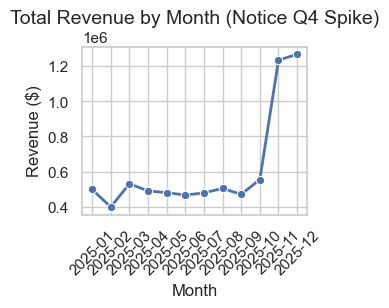

In [15]:
plt.subplot(2, 2, 1)
monthly_revenue = completed_df.groupby('txn_month')['total_revenue'].sum().reset_index()
monthly_revenue['txn_month'] = monthly_revenue['txn_month'].astype(str)
sns.lineplot(data=monthly_revenue, x='txn_month', y='total_revenue', marker='o', linewidth=2, color='b')
plt.title('Total Revenue by Month (Notice Q4 Spike)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)

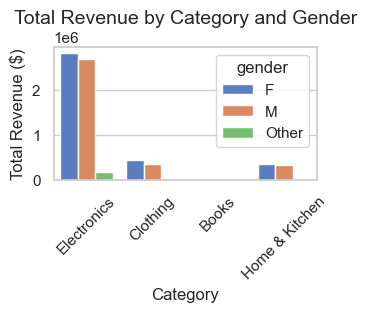

In [18]:
plt.subplot(2, 2, 2)
sns.barplot(data=completed_df, x='product_category', y='total_revenue', hue='gender', estimator=sum, errorbar=None, palette="muted")
plt.title('Total Revenue by Category and Gender', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()

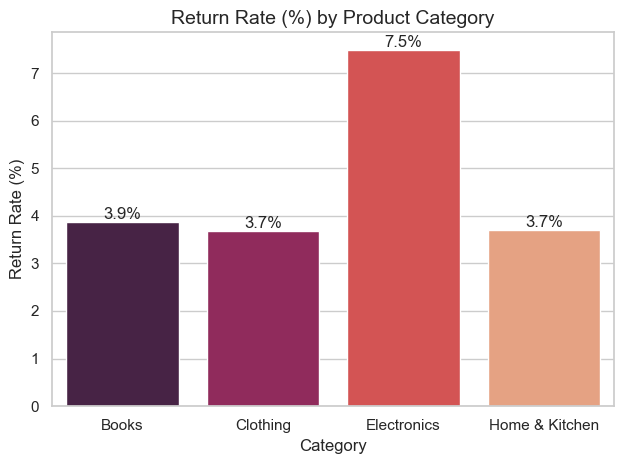

In [37]:
plt.subplot(1, 1, 1)
return_rates = (
df.groupby('product_category')['status']
.apply(lambda x: (x == 'Returned')
.mean() * 100)
.reset_index(name='return_rate'))
ax = sns.barplot(
data=return_rates,
x='product_category',
y='return_rate',
hue='product_category',
palette='rocket')
plt.title('Return Rate (%) by Product Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Return Rate (%)')
for container in ax.containers:ax.bar_label(container, fmt='%.1f%%')
plt.tight_layout()

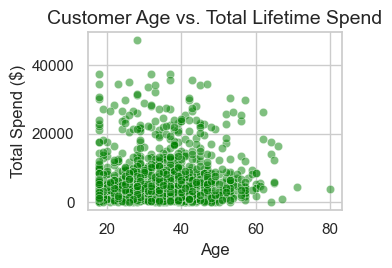

Total Completed Revenue: $7,375,881.65
Overall Return Rate: 4.85%
Top Performing Category:Electronics


In [76]:
plt.subplot(2, 2, 4)
customer_spend = (
completed_df.groupby('customer_id')
.agg({
'age': 'first',
'total_revenue': 'sum'
})
.reset_index()
)
sns.scatterplot(
data=customer_spend,
x='age',
y='total_revenue',
alpha=0.5,
color='green'
)
plt.title('Customer Age vs. Total Lifetime Spend', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Total Spend ($)')
plt.tight_layout()
plt.show()
print(f"Total Completed Revenue: ${completed_df['total_revenue'].sum():,.2f}")
return_rate = (df['status'] == 'Returned').mean() * 100
print(f"Overall Return Rate: {return_rate:.2f}%")
top_category = (
completed_df.groupby('product_category')['total_revenue']
.sum()
.idxmax()
)
print(f"Top Performing Category:{top_category}")
engine.dispose()

In [46]:
print(completed_df['txn_month'].unique())

<PeriodArray>
['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07',
 '2025-08', '2025-09', '2025-10', '2025-11', '2025-12']
Length: 12, dtype: period[M]


In [51]:
nov_dec_revenue = completed_df[
completed_df['transaction_date'].dt.month.isin([11, 12])
]['total_revenue'].sum()
annual_revenue = completed_df['total_revenue'].sum()
percentage = (nov_dec_revenue / annual_revenue) * 100
print(f"Nov-Dec Revenue Contribution: {percentage:.2f}%")

Nov-Dec Revenue Contribution: 33.89%


In [52]:
completed_df.groupby('txn_month')['total_revenue'].sum()

txn_month
2025-01     498875.93
2025-02     398854.01
2025-03     531294.19
2025-04     490213.76
2025-05     480977.80
2025-06     466639.67
2025-07     479026.46
2025-08     504488.04
2025-09     470804.26
2025-10     554837.89
2025-11    1233327.96
2025-12    1266541.68
Freq: M, Name: total_revenue, dtype: float64

In [53]:
customer_spend = (completed_df.groupby('customer_id')
.agg({'age': 'first','total_revenue': 'sum'}).reset_index())
avg_spend_by_age = (customer_spend.assign(age_group=pd.cut(customer_spend['age'],
bins=[18, 25, 35, 45, 55, 65, 100],
labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])).groupby('age_group')['total_revenue'].mean().reset_index(name='avg_customer_spend'))
print(avg_spend_by_age)

  age_group  avg_customer_spend
0     18-25         6773.885373
1     26-35         7562.926111
2     36-45         7982.584662
3     46-55         6691.003252
4     56-65         8087.551667
5       65+         6417.755000


C:\Users\anshi\AppData\Local\Temp\ipykernel_4772\2231127397.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])).groupby('age_group')['total_revenue'].mean().reset_index(name='avg_customer_spend'))


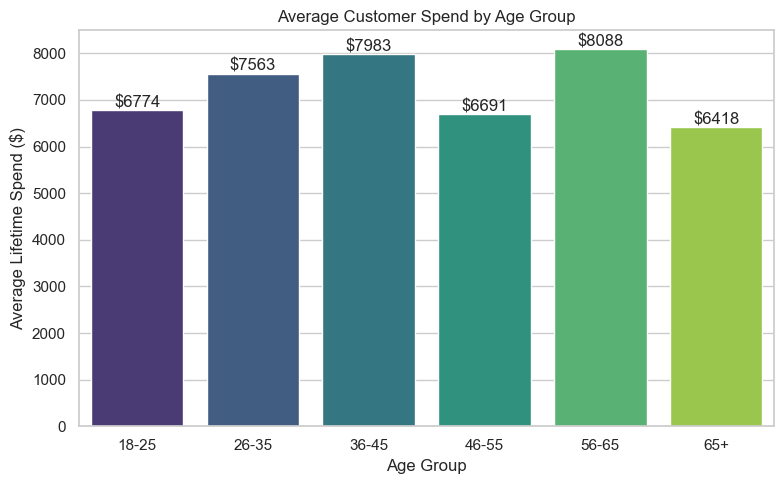

In [65]:
plt.figure(figsize=(8,5))
ax = sns.barplot(
data=avg_spend_by_age,
x='age_group',
y='avg_customer_spend',
hue='age_group',
palette='viridis',
legend=False
)
for container in ax.containers:ax.bar_label(container,fmt='$%.0f')
plt.title('Average Customer Spend by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Lifetime Spend ($)')
plt.savefig("avg_customer_spend_by_age.png", dpi=300)
plt.tight_layout()
plt.show()

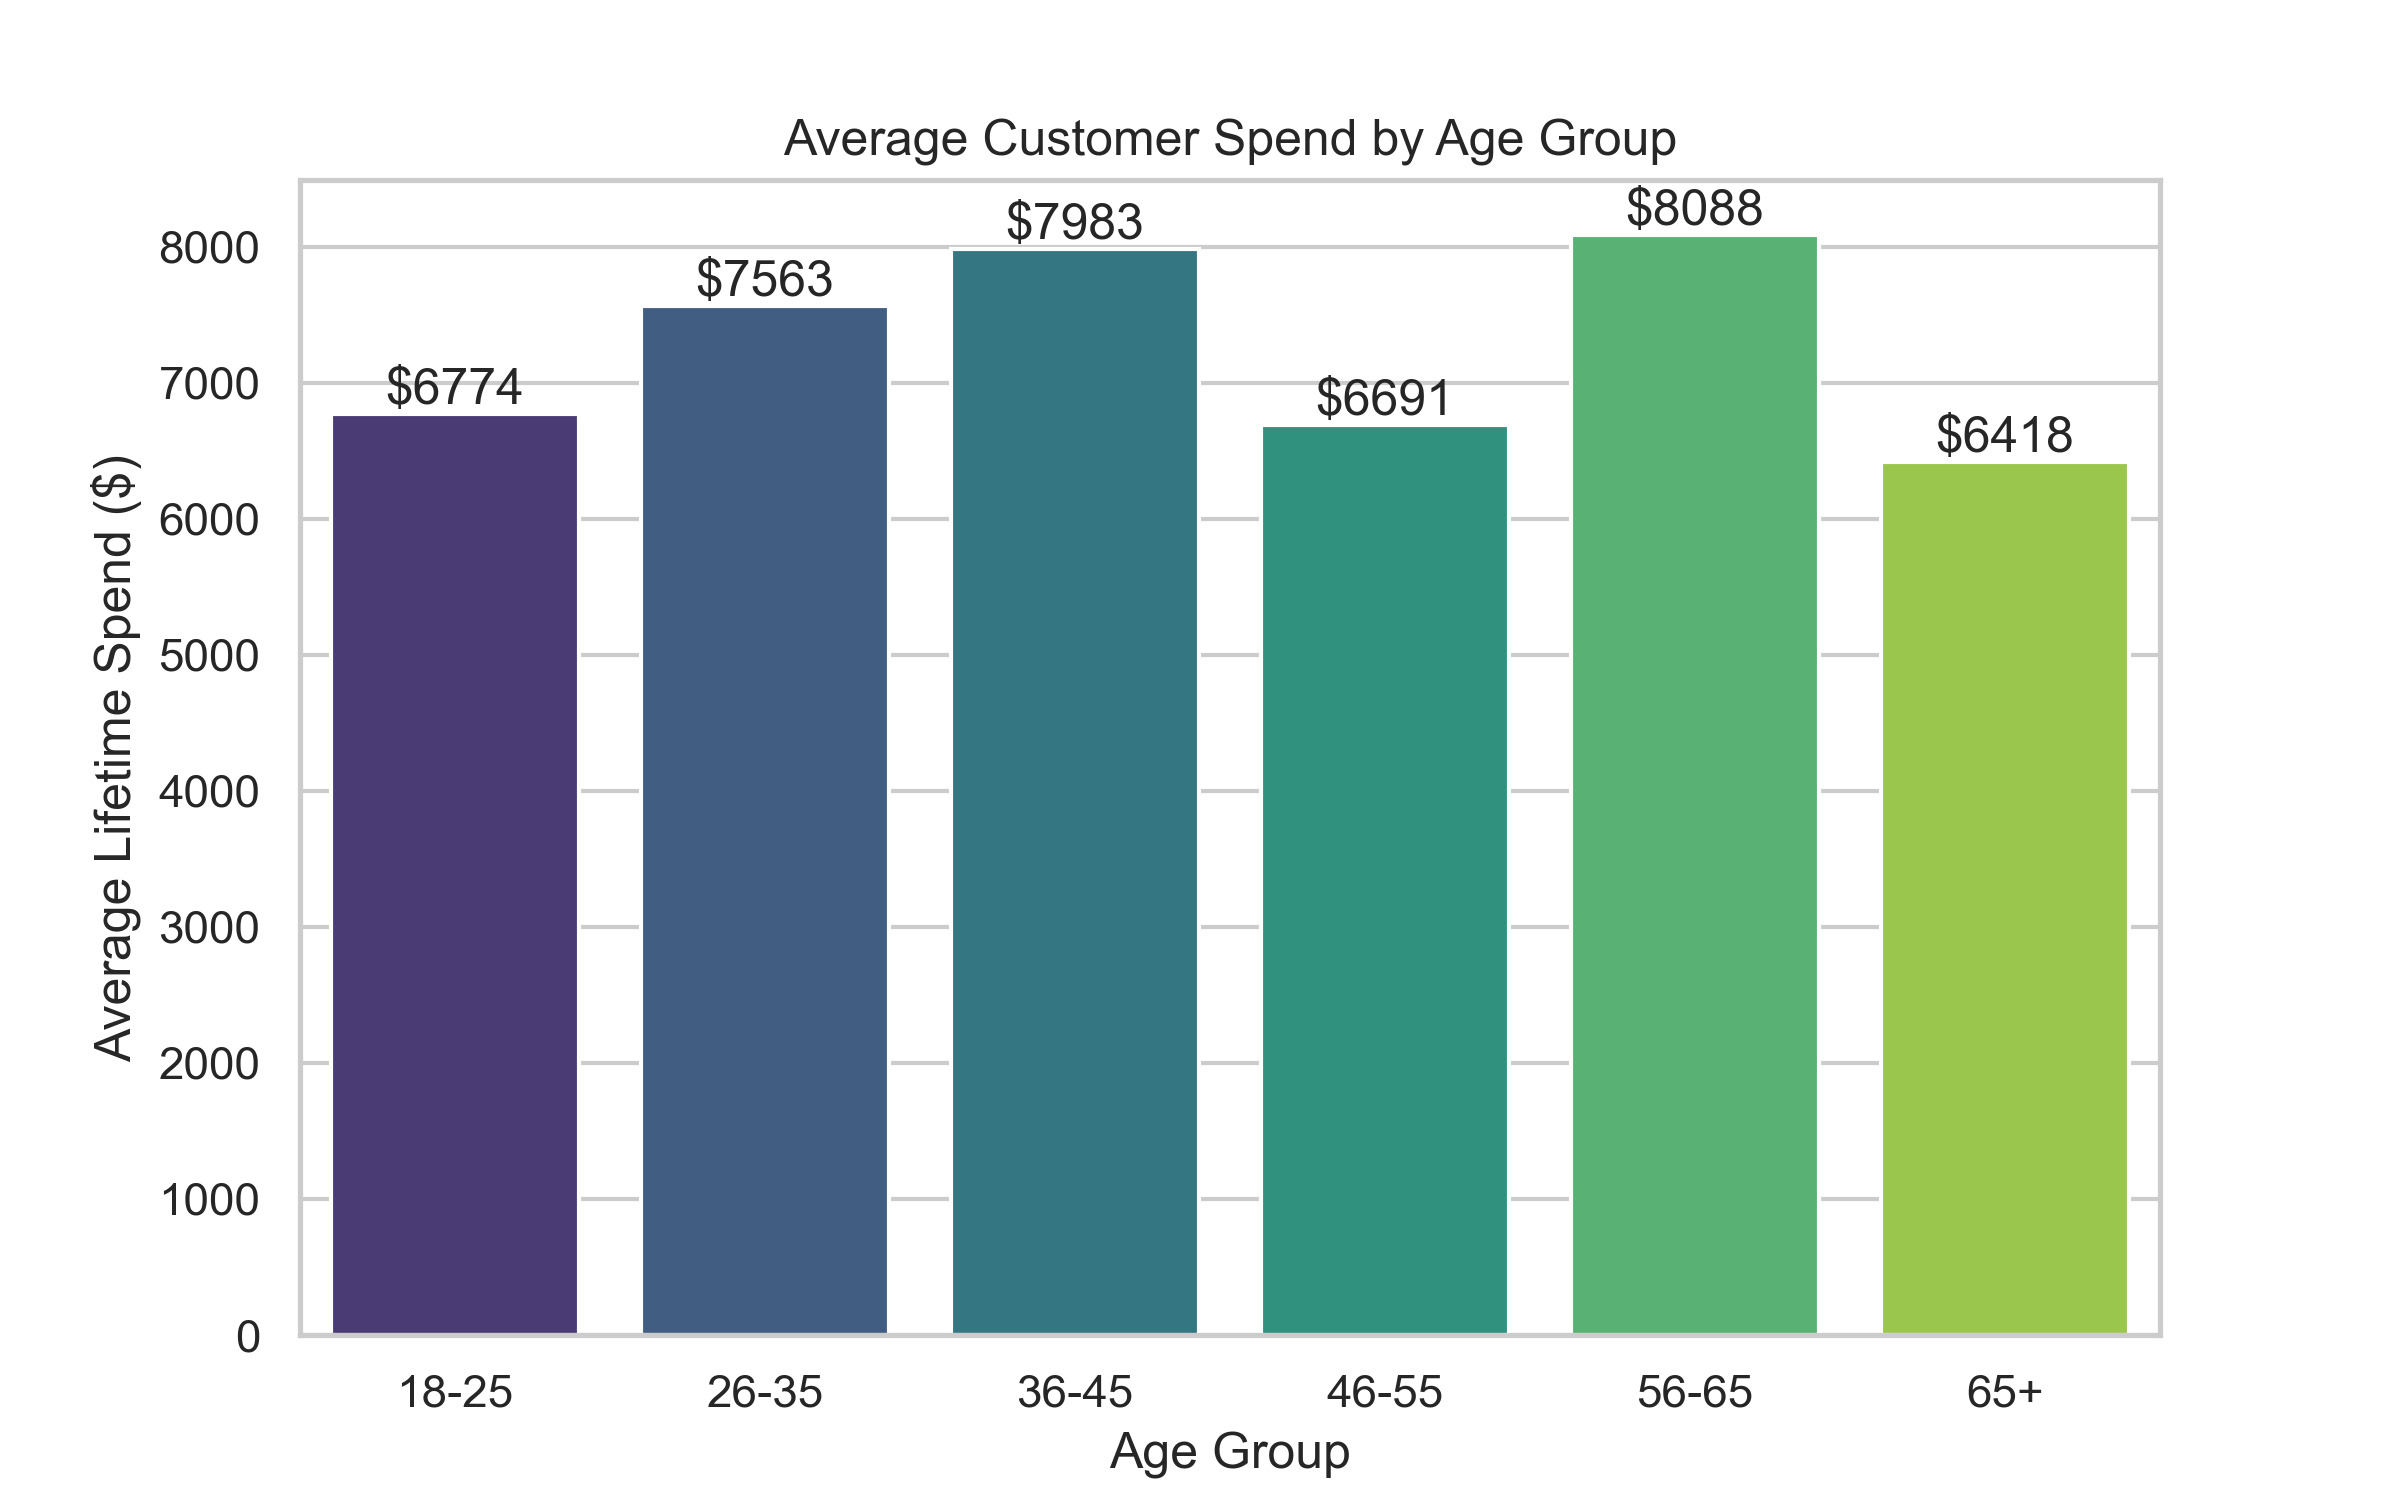

In [64]:
from IPython.display import Image, display
# Display the saved PNG file
display(Image(filename='eda_dashboard.png'))

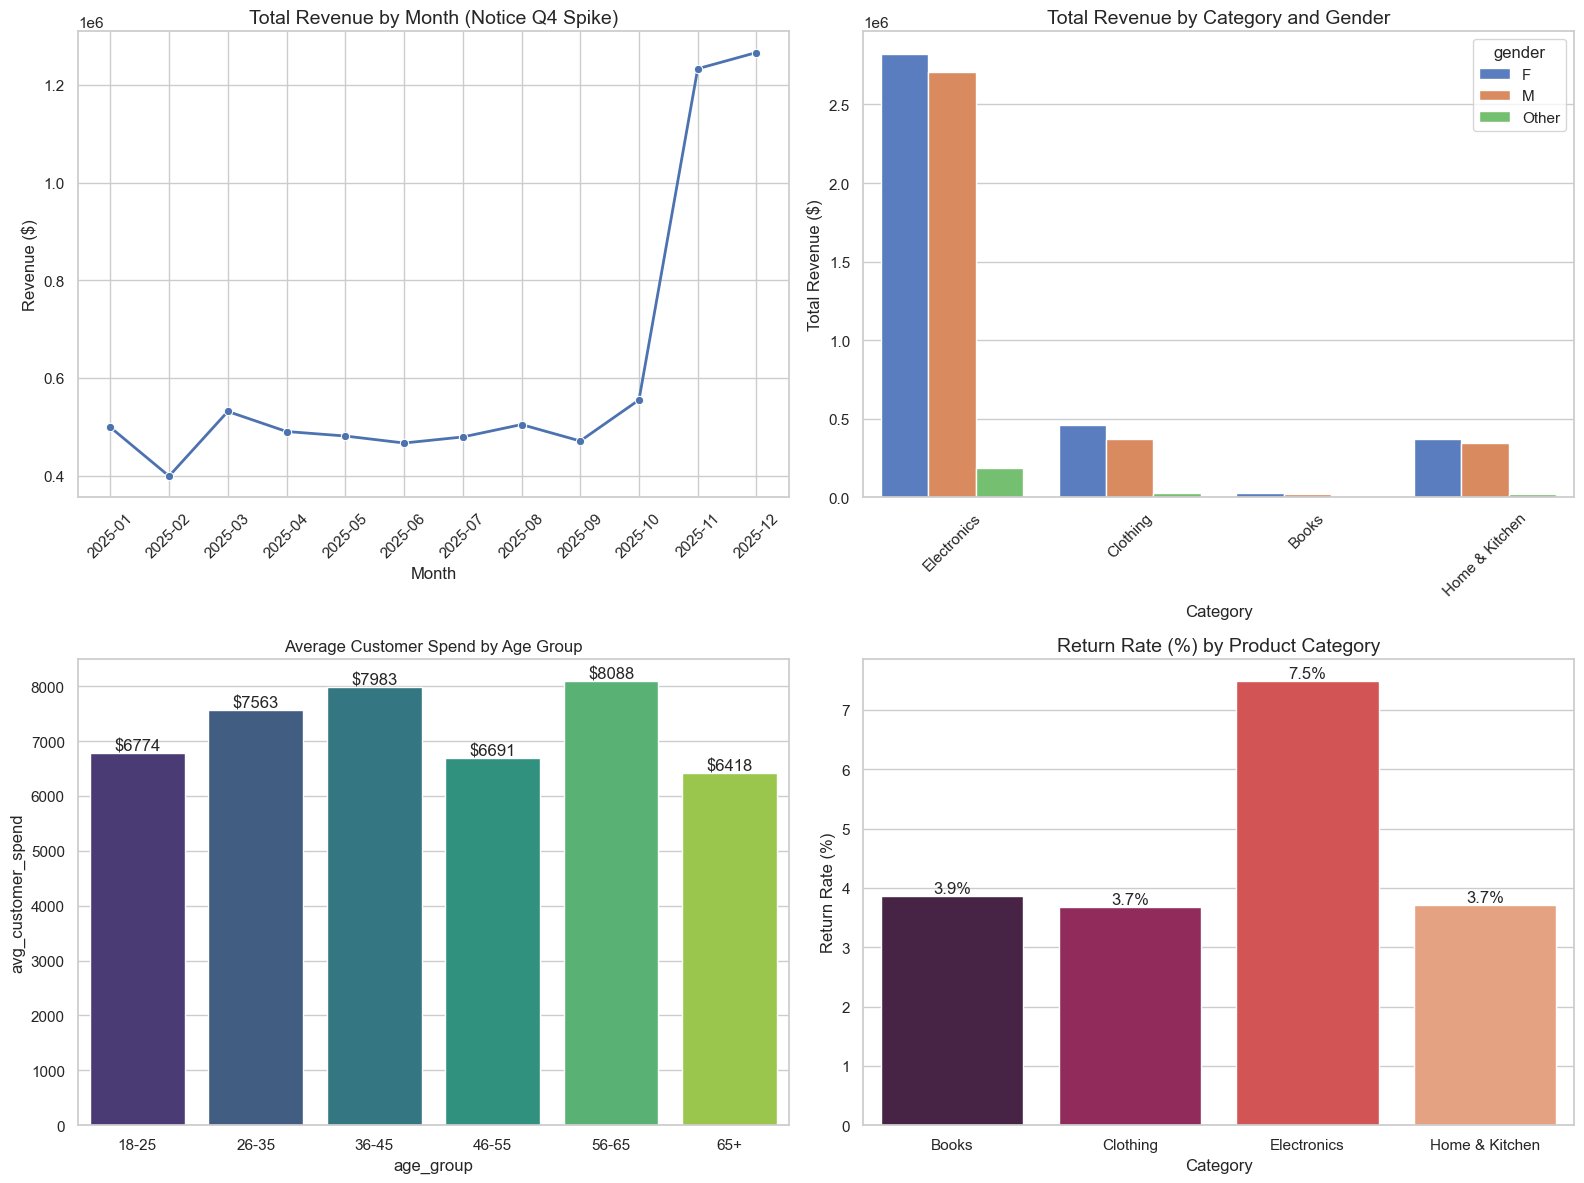

In [86]:
plt.figure(figsize=(16, 12))
plt.subplot(2, 2, 1)
monthly_revenue = completed_df.groupby('txn_month')['total_revenue'].sum().reset_index()
monthly_revenue['txn_month'] = monthly_revenue['txn_month'].astype(str)
sns.lineplot(data=monthly_revenue, x='txn_month', y='total_revenue', marker='o', linewidth=2, color='b')
plt.title('Total Revenue by Month (Notice Q4 Spike)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.subplot(2, 2, 2)
sns.barplot(data=completed_df, x='product_category', y='total_revenue', hue='gender', estimator=sum, errorbar=None, palette="muted")
plt.title('Total Revenue by Category and Gender', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.subplot(2, 2, 3)
ax = sns.barplot(
data=avg_spend_by_age,
x='age_group',
y='avg_customer_spend',
hue='age_group',
palette='viridis',
legend=False
)
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f')
plt.title('Average Customer Spend by Age Group')
plt.subplot(2, 2, 4)
return_rates = (
df.groupby('product_category')['status']
.apply(lambda x: (x == 'Returned')
.mean() * 100)
.reset_index(name='return_rate'))
ax = sns.barplot(
data=return_rates,
x='product_category',
y='return_rate',
hue='product_category',
palette='rocket')
plt.title('Return Rate (%) by Product Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Return Rate (%)')
for container in ax.containers:ax.bar_label(container, fmt='%.1f%%')
plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=300)
plt.show()